# Experiment 2 — Does the Stopping Rule Actually Work?

**Claims under test** (experiment proposal, C1 & C2; design paper §3.2–§3.3, Theorem 1, Assumption 1(a)):

- **C1** — The unseen-mass estimate $\hat U + \psi$ stays *above* the true unseen mass at every step,
  even though the agent picks its own searches and its own stopping time.
- **C2** — When the agent decides to stop, realized recall really is $\ge 1-\varepsilon$
  (at rate $\ge 1-\delta$ across entities).

**The idea in one paragraph.** The agent searches the open web for a company's funding rounds while the
authoritative registry (SEC EDGAR) is *deliberately hidden from it*. Separately, we build the true answer
key from that same registry. The agent must therefore decide "have I seen enough?" using only its own
statistics — the Good–Turing singleton signal $\hat U$, the confidence radius $\psi$, and the frontier of
still-pending searches — and afterwards we can grade, from the withheld answer key, whether its promise
held. This is the paper's central instrument: the **withheld-registry oracle** (§9).

**Design (one live run, four $\varepsilon$ arms).** The proposal asks for runs at
$\varepsilon \in \{0.30, 0.20, 0.10, 0.05\}$. But $\varepsilon$ enters the agent *only* at the final
stop comparison (`all_strata_pass`, paper §3.3) — search selection, extraction, and every logged statistic
are $\varepsilon$-free. A single live run at the **strictest** $\varepsilon=0.05$ therefore contains every
looser-$\varepsilon$ run as an *exact prefix*, and the other three arms can be **replayed offline** from
the per-step log — 4 arms for the price of 1, with zero approximation. A self-test cell below proves the
replay reproduces the live run's own stop exactly.

**Outputs** (all regenerable offline from the run logs):

| # | Figure / table | What it shows | Claim |
|---|---|---|---|
| 1 | `exp2_calibration.pdf` | predicted vs. realized unseen mass — the direct audit of Assumption 1(a) | C1 |
| 2 | `exp2_coverage.pdf` | realized recall at each stop vs. the promised $1-\varepsilon$ | C2 |
| 3 | `exp2_trajectory.pdf` | one entity's full journey: the estimate falling, four stop points | C1, C2 |
| 4 | `exp2_cost_recall.pdf` | adaptive stopping vs. a fixed-budget baseline at equal cost | C2 |
| — | `exp2_stop_table.csv`, `exp2_summary_by_eps.csv` | per-(entity, ε) stops and the per-ε roll-up | both |

**What would falsify the claims** (stated *before* looking at results):
points **above** the diagonal in Figure 1 would falsify Assumption 1(a) and with it the whole stopping
story; a violation rate **above $\delta$** among certified stops in Figure 2 would falsify Theorem 1's
empirical content; and if every run ends "budget"/"max_steps" with nothing certified, the guarantee is
too conservative to be useful — an honest negative result the paper would have to report.

## Prerequisites — real pipeline only, no degraded modes

This notebook runs the **real** pipeline end to end: real Serper searches, real LLM extraction, the
fitted conformal gate (seam A1), the fitted entity-resolution matcher with live LLM adjudication
(seam A2), against real per-entity dollar budgets. The preflight below **refuses to run** if any seam
would silently degrade (the repo's fake-in-path discipline).

Before running:

1. **Instrumentation patch** — `webagg/pipeline.py` must log `hot`, `certified`, `spent`, and
   `formulation_id` in every per-step `U_hat` measurement (the Exp-2 patch). Preflight checks the
   source directly.
2. **Ground truth** — build the validation cohort's answer keys first (uses EDGAR, *outside* the agent):
   ```powershell
   python scripts\build_truth.py --cohort formd_v1 --ciks <...validation ciks...>
   ```
   The cohort manifest must contain a frozen `split` with a non-empty `validation` list. The
   calibration half is *never* graded here (it belongs to seam A3 / Experiment 6).
3. **Seams A1 + A2 closed** — `data/calibration/extraction_cal.json` present (gate refuses bootstrap
   accept-all), and `data/ground_truth/match_pairs.csv` big enough that the matcher is warm
   (`alpha` fitted, not cold-start).
4. **Keys & stack** — `.env` with `SERPER_API_KEY` plus the LLM provider key; `torch` +
   `sentence-transformers` importable (the real matcher embeds surfaces).

**Cost estimate.** One live entity ≈ one `certify_fidelity.py` reference run: up to `BUDGET_USD`
(default \$5) in search + LLM spend, tens of steps. Runs are **resumable** — an entity whose run DB and
records file already exist is skipped with a printed notice, so a crash costs nothing but the restart.

**Windows note.** Every SQLite session is explicitly closed and its engine disposed before any file
operation (the repo's PowerShell/Windows lesson).

In [1]:
# --- imports, repo root, and the PRE-REGISTERED parameters -------------------
# Everything an arm of this experiment depends on is fixed HERE, before any
# result is looked at (repo principle: pre-register grading decisions).
from __future__ import annotations

import json
import os
import sys
import inspect
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# repo root: the notebook lives in notebooks/, the package one level up
ROOT = Path.cwd()
if not (ROOT / "webagg").exists():
    ROOT = ROOT.parent
assert (ROOT / "webagg").exists(), f"cannot find the webagg package from {Path.cwd()}"
sys.path.insert(0, str(ROOT))
# webagg opens prompts/ and data/ RELATIVE to the working directory (that is
# why scripts and pytest run from the repo root). Jupyter starts in
# notebooks/, so move to the root -- every relative path below then means
# exactly what it means in a CLI run.
os.chdir(ROOT)

from webagg import config, pipeline                       # the real pipeline
from webagg.storage import (get_session, MeasurementRow,  # the measurement spine
                            MentionRow, SourceRow, FrontierFormulationRow)
from webagg.certify import entity_query, query_name, REGISTRY_DENY
from webagg.formd import load_truth_cohort
from webagg.risk_control import match_to_truth, default_truth_key

# ---- pre-registered experiment parameters -----------------------------------
EPS_GRID   = [0.30, 0.20, 0.10, 0.05]   # the proposal's four arms
EPS_STRICT = min(EPS_GRID)              # the ONE live arm; others replay offline
DELTA      = config.DELTA_M             # psi confidence budget (paper delta_M)
ETA        = config.ETA                 # hot-frontier threshold (conjunct ii)
MAX_STEPS  = 60                         # frontier cap, matching A3 reference runs
BUDGET_USD = config.BUDGET_USD          # REAL per-entity spend cap (default $5)
COHORT     = "formd_v1"                 # cohort under data/ground_truth/
AMOUNT_TOL = 0.05                       # pre-registered grading tolerance (A3
                                        # attempt #3): undated records may align
                                        # to truth by relative amount distance
QUERY_ATTRS = {"amount", "date"}        # same pair the certification runs use
RECALL_TARGET_FOR_FIG4 = 0.10           # the eps whose target Figure 4 examines

# open-web name overrides: the registry files LEGAL names the press never uses
# (the Instacart lesson: EDGAR knows it as "Maplebear Inc.")
NAME_OVERRIDES: dict[str, str] = {
    # "cik0001579091": "Instacart",
}

EXP_DIR = config.DATA_DIR / "experiments" / "exp2"
FIG_DIR = ROOT / "figures"
EXP_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# one shared, colorblind-safe color per eps arm, used by every figure
EPS_COLOR = dict(zip(EPS_GRID, ["#0072B2", "#009E73", "#E69F00", "#D55E00"]))

plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
print(f"repo root : {ROOT}")
print(f"arms      : eps in {EPS_GRID} (live at {EPS_STRICT}, rest replayed)")
print(f"budget    : ${BUDGET_USD:.2f}/entity, max {MAX_STEPS} steps, delta={DELTA}")

repo root : C:\Users\wangz\PycharmProjects\webagg
arms      : eps in [0.3, 0.2, 0.1, 0.05] (live at 0.05, rest replayed)
budget    : $5.00/entity, max 60 steps, delta=0.1


## Preflight — refuse to run degraded

Each check below guards one seam that could otherwise degrade *silently* and quietly turn a "real"
experiment into a fake one. A failed check stops the notebook with instructions; nothing downstream
runs on a broken seam. (Repo principle: *any seam with graceful degradation needs at least one live
check that refuses to accept degraded output.*)

In [2]:
# --- preflight: every seam checked LOUDLY, before a dollar is spent ----------
failures: list[str] = []
def check(name: str, ok: bool, fix: str):
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
    if not ok:
        failures.append(f"{name}\n         fix: {fix}")

print("preflight:")

# 1. the Exp-2 instrumentation patch is in pipeline.run_query
src = inspect.getsource(pipeline.run_query)
patched = all(f'"{k}"' in src for k in ("hot", "certified", "spent", "formulation_id"))
check("instrumentation patch (hot/certified/spent/formulation_id logged)", patched,
      "apply the Exp-2 patch to webagg/pipeline.py (see the patch instructions)")

# 2. cohort manifest with a frozen validation split
cohort_dir = config.GROUND_TRUTH_DIR / COHORT
manifest_path = cohort_dir / "manifest.json"
manifest = json.loads(manifest_path.read_text()) if manifest_path.exists() else None
val_ids = (manifest or {}).get("split", {}).get("validation", [])
check(f"cohort manifest with non-empty validation split ({len(val_ids)} entities)",
      bool(val_ids),
      f"run scripts/build_truth.py --cohort {COHORT} ... to build truth + split")

# 3. every validation entity has its answer key on disk
truths = load_truth_cohort(cohort_dir) if val_ids else {}
missing_truth = [e for e in val_ids if e not in truths]
check("answer keys present for all validation entities", not missing_truth,
      f"build_truth.py is missing: {missing_truth}")

# 4. seam A1: the conformal gate must be fittable (no bootstrap accept-all)
from webagg.calibration import ConformalGate, load_calibration_set
cal = load_calibration_set(config.CALIBRATION_SET)
check(f"A1 conformal gate calibration set ({len(cal)} pairs)", bool(cal),
      f"seam A1: build {config.CALIBRATION_SET} (scripts/build_calibration.py)")

# 5. seam A2: the matcher must be WARM (fitted alpha), and torch importable
try:
    from webagg.er_pairs import load_fitted_matcher
    _m = load_fitted_matcher()
    a2_ok, a2_msg = _m.alpha is not None, f"alpha={_m.alpha}"
except Exception as e:                                   # torch missing etc.
    a2_ok, a2_msg = False, repr(e)
check(f"A2 fitted ER matcher ({a2_msg})", a2_ok,
      "seam A2: label pairs (scripts/build_er_pairs.py) + install torch/"
      "sentence-transformers; the cold-start matcher is refused here")

# 6. API keys for the REAL run (search + LLM)
check("SERPER_API_KEY present", bool(config.SERPER_API_KEY), "add it to .env")
llm_key = bool(config.ANTHROPIC_API_KEY) or bool(__import__("os").environ.get("OPENAI_API_KEY"))
check("LLM provider key present", llm_key, "add ANTHROPIC_API_KEY or OPENAI_API_KEY to .env")

# 7. the denylist grammar resolves ("sec" -> sec.gov) -- a typo would deny nothing
from webagg.denylist import normalize
check("denylist normalize(['sec']) == ('sec.gov',)",
      normalize(["sec"]) == ("sec.gov",), "webagg.denylist is broken")

if failures:
    raise RuntimeError("preflight FAILED -- refusing to run degraded:\n  - "
                       + "\n  - ".join(failures))
print(f"\nall checks passed. validation entities: {val_ids}")

preflight:
  [PASS] instrumentation patch (hot/certified/spent/formulation_id logged)
  [PASS] cohort manifest with non-empty validation split (2 entities)
  [PASS] answer keys present for all validation entities
  [PASS] A1 conformal gate calibration set (111 pairs)
[er] matcher fitted on 280 labeled pairs (37 same / 243 different); alpha=0.1321
  [PASS] A2 fitted ER matcher (alpha=0.13214285714285715)
  [PASS] SERPER_API_KEY present
  [PASS] LLM provider key present
  [PASS] denylist normalize(['sec']) == ('sec.gov',)

all checks passed. validation entities: ['cik0001181412', 'cik0001321655']


## Why one live run per entity is enough (and 4× cheaper)

Think of the agent as a field biologist estimating how many species remain unseen in a forest. Each
search is a day of trapping; each funding round is a species; catching a species *twice* is evidence the
forest is getting exhausted, while a day full of first-time catches ($f_1$, the **singletons**) says
much remains. Good–Turing turns that into the unseen-mass estimate $\hat U$, the radius $\psi$ prices
the statistical luck, and the **frontier credit** adds mass for promising traps not yet set (a pending
search still expected to yield $\ge \eta$ new records keeps the stratum *hot* — conjunct ii).

The threshold $\varepsilon$ is only the line the falling curve $\hat U + \psi$ must cross before the
biologist may go home. **It never influences which trap is set next** — in code, `eps` is read exactly
once, inside `all_strata_pass` (paper §3.3). So the $\varepsilon=0.05$ expedition walks the *identical*
path an $\varepsilon=0.30$ expedition would have walked; the looser expedition merely goes home earlier.
Logging, at every step, everything the stop test reads — $\hat U$, $\psi$, the hot flag, checksum
certificates, cumulative spend — lets us re-ask "would it have stopped here?" offline for any
$\varepsilon$, and the answer is *exact*, not simulated. Steps 1–2 below run the live expedition;
everything after is offline replay.

In [3]:
# --- STEP 1 (LIVE): one real end-to-end run per validation entity ------------
# Mirrors pipeline.end_to_end's open-web branch, inlined so the session can be
# disposed on Windows. Everything is the production path: real Serper, real
# LLM extraction behind the fitted gate, registry DENIED, then the real ER
# matcher + corroboration. Idempotent: finished entities are skipped LOUDLY.
INDEX_PATH = EXP_DIR / "exp2_runs_index.json"
runs_index = json.loads(INDEX_PATH.read_text()) if INDEX_PATH.exists() else {}

def _cv_plain(cv):
    """CorroboratedValue -> plain dict of exactly what grading reads."""
    if cv is None:
        return None
    return {"value": getattr(cv, "value", None),
            "value_num": getattr(cv, "value_num", None)}

for eid in val_ids:
    name = query_name(manifest, eid, NAME_OVERRIDES)
    run_id = f"exp2_{eid}"
    db = config.RUNS_DIR / f"{run_id}.sqlite"
    rec_path = EXP_DIR / f"records_{eid}.json"
    if eid in runs_index and db.exists() and rec_path.exists():
        print(f"[exp2] {eid} ({name}): run exists -- skip")
        continue

    print(f"[exp2] {eid} ({name}): LIVE run, eps={EPS_STRICT}, "
          f"deny={list(REGISTRY_DENY)}, budget=${BUDGET_USD:.2f} ...")
    # discovery: the frontier loop at the STRICTEST eps (paper Thm 1 regime)
    state, session = pipeline.run_query(
        entity_query(name), run_id=run_id,
        eps=EPS_STRICT, delta=DELTA, eta=ETA,
        max_steps=MAX_STEPS, budget_usd=BUDGET_USD,
        query_attributes=QUERY_ATTRS, deny=REGISTRY_DENY)
    try:
        # resolution: real fitted matcher (+ live LLM adjudicator on the band),
        # post-ER checksum revalidation via state (design §14.1)
        result = pipeline.resolve_and_aggregate(
            session, run_id=run_id, query_attributes=QUERY_ATTRS,
            aggregate_attr="amount", eps=EPS_STRICT, state=state,
            mode="open_web", delta_M=DELTA, max_steps=MAX_STEPS)
    finally:
        engine = session.get_bind()
        session.close()
        engine.dispose()            # Windows: release the sqlite handle

    # persist the REAL resolved records verbatim (resumability, offline grading)
    plain = [{"entity_id": r.get("entity_id") if isinstance(r, dict) else r.entity_id,
              "record_kind": r.get("record_kind") if isinstance(r, dict) else r.record_kind,
              "attributes": {a: _cv_plain(cv) for a, cv in
                             ((r.get("attributes") or {}) if isinstance(r, dict)
                              else (r.attributes or {})).items()},
              # LOUD (repo discipline): a record without its provenance handle
              # must crash here, not silently grade to recall 0 downstream
              "contributing_mentions": (r["contributing_mentions"]
                                        if isinstance(r, dict)
                                        else list(r.contributing_mentions))}
             for r in result["records"]]
    rec_path.write_text(json.dumps(plain, indent=1))
    runs_index[eid] = {"db": str(db), "run_id": run_id, "entity_name": name,
                       "query": entity_query(name), "eps": EPS_STRICT,
                       "delta": DELTA, "eta": ETA, "max_steps": MAX_STEPS,
                       "budget_usd": BUDGET_USD, "deny": list(REGISTRY_DENY),
                       "n_records": len(plain)}
    INDEX_PATH.write_text(json.dumps(runs_index, indent=2, sort_keys=True))
    print(f"[exp2] {eid}: done -- {len(plain)} resolved records")

done = [e for e in val_ids if e in runs_index]
print(f"\nlive phase complete: {len(done)}/{len(val_ids)} entities")

[exp2] cik0001181412 (SPACE EXPLORATION TECHNOLOGIES CORP): LIVE run, eps=0.05, deny=['sec.gov', 'www.sec.gov', 'data.sec.gov'], budget=$5.00 ...
[er] matcher fitted on 280 labeled pairs (37 same / 243 different); alpha=0.1321


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[exp2] cik0001181412: done -- 7 resolved records
[exp2] cik0001321655 (Palantir Technologies Inc.): LIVE run, eps=0.05, deny=['sec.gov', 'www.sec.gov', 'data.sec.gov'], budget=$5.00 ...
[er] matcher fitted on 280 labeled pairs (37 same / 243 different); alpha=0.1321
[exp2] cik0001321655: done -- 10 resolved records

live phase complete: 2/2 entities


## Step 2 (offline): load the per-step ledger

Every step of every run left one row per stratum in the run's measurement log — a ledger of exactly
what the stop test could see at that moment: the estimate $\hat U$, the radius $\psi$, whether a hot
search was still pending, whether a checksum had already closed the stratum, and the money spent so
far. All analysis below reads only this ledger plus the run DB's mentions — **no new fetches, no new
LLM calls**.

In [4]:
# --- load every run's per-step, per-stratum stop-test inputs -----------------
def load_step_log(db_path: str, run_id: str) -> tuple[pd.DataFrame, tuple]:
    """The U_hat ledger + the run's actual logged stop (step, reason)."""
    session = get_session(db_path)
    try:
        rows = (session.query(MeasurementRow)
                .filter(MeasurementRow.run_id == run_id,
                        MeasurementRow.metric == "U_hat")
                .order_by(MeasurementRow.step).all())
        recs = [dict(step=r.step, stratum=r.stratum, U=r.value,
                     **{k: (r.extra or {}).get(k)
                        for k in ("psi", "N", "f1", "f2", "hot", "certified",
                                  "spent", "claimed_count", "formulation_id")})
                for r in rows]
        stop_row = (session.query(MeasurementRow)
                    .filter(MeasurementRow.run_id == run_id,
                            MeasurementRow.metric == "stop")
                    .order_by(MeasurementRow.step.desc()).first())
        stop = (stop_row.step, (stop_row.extra or {}).get("reason")) if stop_row \
               else (None, None)
    finally:
        engine = session.get_bind(); session.close(); engine.dispose()
    return pd.DataFrame(recs), stop

step_logs: dict[str, pd.DataFrame] = {}
actual_stops: dict[str, tuple] = {}
for eid in done:
    step_logs[eid], actual_stops[eid] = load_step_log(runs_index[eid]["db"],
                                                      runs_index[eid]["run_id"])
    df = step_logs[eid]
    print(f"{eid:>18}: {df['step'].nunique():>3} steps, "
          f"{df['stratum'].nunique()} strata, actual stop = {actual_stops[eid]}")
assert all(len(v) for v in step_logs.values()), "an entity logged no U_hat rows"

     cik0001181412:  26 steps, 1 strata, actual stop = (27, 'frontier_exhausted')
     cik0001321655:   1 steps, 1 strata, actual stop = (2, 'economic')


## Step 3 (offline): replay the stop decision at every ε

The function below is a line-for-line offline mirror of the pipeline's stop test
(`all_strata_pass` + the budget guard, in the loop's exact order): a run stops at the first step where
**every** not-yet-certified stratum has (i) $\hat U + \psi < \varepsilon$, (ii) no hot pending search,
and (iii) no cardinality brake armed — unless the budget ran out first. Because the live path is
$\varepsilon$-free, applying this at a looser $\varepsilon$ recovers *exactly* the run that looser agent
would have executed.

In [5]:
# --- the offline stop-rule replay (mirror of pipeline.all_strata_pass) -------
def replay_stop(df: pd.DataFrame, eps: float, budget_usd: float,
                terminal: tuple) -> tuple[int, str]:
    """First step at which the eps-agent would have stopped, and why.
    `terminal` = the live run's own (step, reason), inherited when no stop
    fires inside the logged prefix (the looser agent would have hit the same
    budget/max_steps/frontier wall at the same moment)."""
    for step, grp in df.groupby("step", sort=True):
        if float(grp["spent"].max()) >= budget_usd:      # budget checked FIRST,
            return int(step), "budget"                   # as in the live loop
        ok = True
        for row in grp.itertuples():
            if row.certified:                            # checksum-closed: exempt
                continue
            if row.claimed_count is not None and row.N < row.claimed_count:
                ok = False; break                        # cardinality brake (App. E)
            if not (row.U + row.psi < eps):
                ok = False; break                        # conjunct (i): certificate
            if row.hot:
                ok = False; break                        # conjunct (ii): hot frontier
        if ok and len(grp) > 0:                          # cold-start guard
            return int(step), "certified"
    return terminal                                      # never fired in the prefix

stop_rows = []
for eid in done:
    df, term = step_logs[eid], actual_stops[eid]
    spent_at = df.groupby("step")["spent"].max()
    for eps in EPS_GRID:
        s, why = replay_stop(df, eps, BUDGET_USD, term)
        stop_rows.append(dict(entity=eid, eps=eps, stop_step=s, reason=why,
                              spent=float(spent_at.get(s, np.nan))))
stops = pd.DataFrame(stop_rows)
stops.pivot_table(index="entity", columns="eps",
                  values="stop_step").astype("Int64")

eps,0.05,0.10,0.20,0.30
entity,,,,
cik0001181412,27,27,27,27
cik0001321655,2,2,2,2


In [6]:
# --- SELF-TEST: the replay must reproduce reality, or nothing else counts ----
# (repo's loud-failure discipline: a replay that cannot reproduce the live
# run's own stop at the live eps would invalidate every offline arm)
for eid in done:
    got = replay_stop(step_logs[eid], EPS_STRICT, BUDGET_USD, actual_stops[eid])
    assert got == actual_stops[eid], (
        f"replay diverges from reality for {eid}: replay={got}, "
        f"actual={actual_stops[eid]} -- instrumentation or replay logic is wrong")

# monotonicity: a looser promise can never require MORE search
for eid, grp in stops.groupby("entity"):
    seq = grp.sort_values("eps", ascending=False)["stop_step"].tolist()
    assert seq == sorted(seq), f"non-monotone stop steps for {eid}: {seq}"

print(f"self-test passed: strict-eps replay == live stop for all {len(done)} "
      f"entities; stop steps monotone in eps.")

self-test passed: strict-eps replay == live stop for all 2 entities; stop steps monotone in eps.


## Step 4 (offline): grade each stop against the withheld answer key

Two bookkeeping moves turn the logs into per-step recall:

1. **When was each record found?** Every mention points to its source page, every page to the search
   that fetched it, and the ledger records which search ran at which step — so each resolved record
   inherits the step of its *earliest* supporting mention.
2. **Which records are real?** The run's resolved records are aligned one-to-one with the registry's
   truth records using the repo's own grading functions (`match_to_truth`), with the pre-registered
   5 % amount tolerance for press rounds that lack a resolvable date. **Recall at step $t$** = the
   fraction of truth records whose first evidence had arrived by step $t$; the **realized unseen
   fraction** is its complement. This grading is exact at the live stop; at earlier replayed stops it
   uses the final entity-resolution clustering restricted to the prefix (noted in Limitations).

In [7]:
# --- discovery-step attribution + per-step recall against the oracle ---------
def load_mention_steps(db_path: str, run_id: str, df: pd.DataFrame) -> dict[str, int]:
    """mention_id -> step at which its source was fetched.
    Route: mention -> source -> formulation_id -> ledger step. Fallback for a
    formulation missing from the ledger (a step that raised no stratum rows):
    the step the formulation was PROPOSED (errs early; counted + reported)."""
    fid_step = df.groupby("formulation_id")["step"].min().to_dict()
    session = get_session(db_path)
    try:
        prop = {f.formulation_id: f.step for f in
                session.query(FrontierFormulationRow).filter_by(run_id=run_id)}
        src_fid = {s.source_id: s.formulation_id for s in session.query(SourceRow)}
        pairs = [(m.mention_id, m.source_id) for m in session.query(MentionRow)]
    finally:
        engine = session.get_bind(); session.close(); engine.dispose()
    out, fell_back = {}, 0
    for mid, sid in pairs:
        fid = src_fid.get(sid)
        if fid in fid_step:
            out[mid] = int(fid_step[fid])
        else:
            out[mid] = int(prop.get(fid, 1)) or 1
            fell_back += 1
    if fell_back:
        print(f"    note: {fell_back}/{len(pairs)} mentions attributed via "
              f"proposal-step fallback")
    return out

def load_records(eid: str) -> list[dict]:
    """The run's REAL resolved records, reshaped so risk_control's graders
    (dict records whose attribute values expose .value/.value_num) accept them."""
    out = []
    for r in json.loads((EXP_DIR / f"records_{eid}.json").read_text()):
        attrs = {a: (SimpleNamespace(**cv) if cv else None)
                 for a, cv in r["attributes"].items()}
        out.append({"entity_id": r["entity_id"], "record_kind": r["record_kind"],
                    "attributes": attrs,
                    "contributing_mentions": r["contributing_mentions"]})
    return out

records_by_eid, first_step_by_eid = {}, {}
for eid in done:
    recs = load_records(eid)
    msteps = load_mention_steps(runs_index[eid]["db"], runs_index[eid]["run_id"],
                                step_logs[eid])
    # a record exists once its EARLIEST supporting mention has arrived
    first = [min((msteps.get(m, 10**9) for m in r["contributing_mentions"]),
                 default=10**9) for r in recs]
    records_by_eid[eid], first_step_by_eid[eid] = recs, first

def recall_at(eid: str, t: int) -> dict:
    """Record + value recall over records whose first evidence arrived by t,
    graded one-to-one against the withheld registry (pre-registered tol)."""
    truth = truths[eid]
    sub = [r for r, s in zip(records_by_eid[eid], first_step_by_eid[eid]) if s <= t]
    aligned = match_to_truth(sub, truth, key_fn=default_truth_key,
                             amount_tol=AMOUNT_TOL)
    hit = [t_ for _, t_ in aligned if t_ is not None]
    return {"record_recall": len(hit) / max(truth.true_count, 1),
            "value_recall": (sum(x.amount for x in hit) / truth.true_sum
                             if truth.true_sum else float("nan"))}

# grade every (entity, eps) arm at its replayed stop step
stops["record_recall"] = [recall_at(r.entity, r.stop_step)["record_recall"]
                          for r in stops.itertuples()]
stops["value_recall"]  = [recall_at(r.entity, r.stop_step)["value_recall"]
                          for r in stops.itertuples()]
stops["promised"]  = 1 - stops["eps"]
stops["violation"] = (stops["reason"] == "certified") & \
                     (stops["record_recall"] < stops["promised"])
stops.round(3)

,entity,eps,stop_step,reason,spent,record_recall,value_recall,promised,violation
0,cik0001181412,0.30,27,frontier_exhausted,NaN,0.2,0.359,0.70,False
1,cik0001181412,0.20,27,frontier_exhausted,NaN,0.2,0.359,0.80,False
2,cik0001181412,0.10,27,frontier_exhausted,NaN,0.2,0.359,0.90,False
3,cik0001181412,0.05,27,frontier_exhausted,NaN,0.2,0.359,0.95,False
4,cik0001321655,0.30,2,economic,NaN,0.5,0.246,0.70,False
5,cik0001321655,0.20,2,economic,NaN,0.5,0.246,0.80,False
6,cik0001321655,0.10,2,economic,NaN,0.5,0.246,0.90,False
7,cik0001321655,0.05,2,economic,NaN,0.5,0.246,0.95,False


## Figure 1 — the calibration plot (the audit of Assumption 1(a))

*"The plot the whole stopping story stands on"* (implementation guide). Each point is one entity at one
step: horizontally, what the agent **predicted** it was still missing ($\hat U + \psi$, taken over its
binding stratum); vertically, what it **actually** was still missing, measured from the withheld
registry. The stopping story survives only if the cloud stays **on or below the diagonal** — the agent
may over-estimate what's left (conservative, costs money) but must never under-estimate it (unsafe,
breaks the guarantee). The right panel shows the raw estimate $\hat U$ without its safety radius, to
make visible how much of the conservatism $\psi$ buys. Replayed stop points are drawn on top in each
arm's color.

points above the diagonal (certificate panel): 0/27


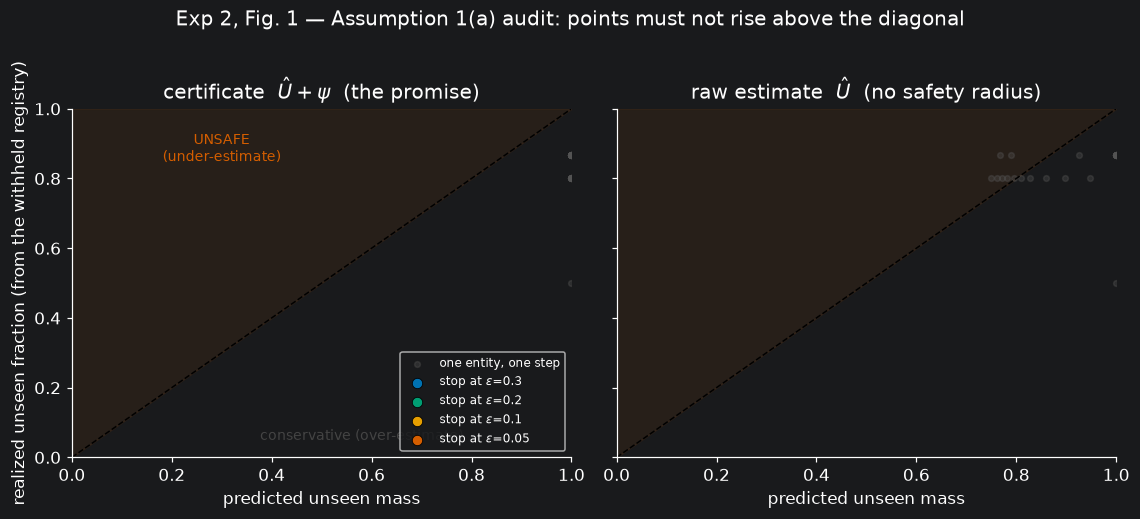

In [8]:
# --- Figure 1: predicted vs realized unseen mass -----------------------------
cal_rows = []
for eid in done:
    df = step_logs[eid]
    per_step = df.groupby("step").apply(
        lambda g: pd.Series({
            # the certificate binds at the WORST uncertified stratum
            "pred_cert": (g.loc[g["certified"].isnull(), "U"]
                          + g.loc[g["certified"].isnull(), "psi"]).max(),
            "pred_U":    g.loc[g["certified"].isnull(), "U"].max()}),
        include_groups=False).dropna()
    for step, row in per_step.iterrows():
        cal_rows.append(dict(entity=eid, step=int(step),
                             pred_cert=min(float(row["pred_cert"]), 1.0),
                             pred_U=min(float(row["pred_U"]), 1.0),
                             realized=1 - recall_at(eid, int(step))["record_recall"]))
cal = pd.DataFrame(cal_rows)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6), sharey=True)
for ax, xcol, ttl in [(axes[0], "pred_cert",
                       r"certificate  $\hat{U}+\psi$  (the promise)"),
                      (axes[1], "pred_U",
                       r"raw estimate  $\hat{U}$  (no safety radius)")]:
    ax.fill_between([0, 1], [0, 1], 1, color="#D55E00", alpha=0.08)
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.scatter(cal[xcol], cal["realized"], s=14, alpha=0.35, color="#555555",
               label="one entity, one step")
    for eps in EPS_GRID:                     # the stop points, per arm
        sel = stops[(stops["reason"] == "certified") & (stops["eps"] == eps)]
        xs = [cal[(cal.entity == r.entity) & (cal.step == r.stop_step)][xcol].max()
              for r in sel.itertuples()]
        ax.scatter(xs, 1 - sel["record_recall"], s=46, zorder=5,
                   color=EPS_COLOR[eps], edgecolor="k", lw=0.5,
                   label=fr"stop at $\varepsilon$={eps}")
    ax.set_xlabel("predicted unseen mass")
    ax.set_title(ttl)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
axes[0].set_ylabel("realized unseen fraction (from the withheld registry)")
axes[0].text(0.30, 0.85, "UNSAFE\n(under-estimate)", color="#D55E00",
             ha="center", fontsize=9)
axes[0].text(0.58, 0.05, "conservative (over-estimate)", color="#444444",
             ha="center", fontsize=9)
axes[0].legend(fontsize=8, loc="lower right")
fig.suptitle("Exp 2, Fig. 1 — Assumption 1(a) audit: points must not rise "
             "above the diagonal", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "exp2_calibration.pdf", bbox_inches="tight")
n_bad = int((cal["realized"] > cal["pred_cert"] + 1e-9).sum())
print(f"points above the diagonal (certificate panel): {n_bad}/{len(cal)}")

## Figure 2 — promise vs. delivery (coverage of the stopping guarantee)

For each arm the agent promised "*when I stop, I'll have found at least $1-\varepsilon$ of the truth*."
Each dot is one entity's realized recall at the moment that arm stopped; the dashed line is the
promise. Filled dots are **certified** stops — the only ones that made a promise; hollow dots stopped
for budget or step-cap reasons and promised nothing (the pipeline explicitly labels these
*not a certificate*). Theorem 1 allows the promise to fail on at most a $\delta$ fraction of certified
stops — the count printed under each column is the check.

certified stops: 0  violations: 0  rate: 0.000  (theorem allows <= delta = 0.1)


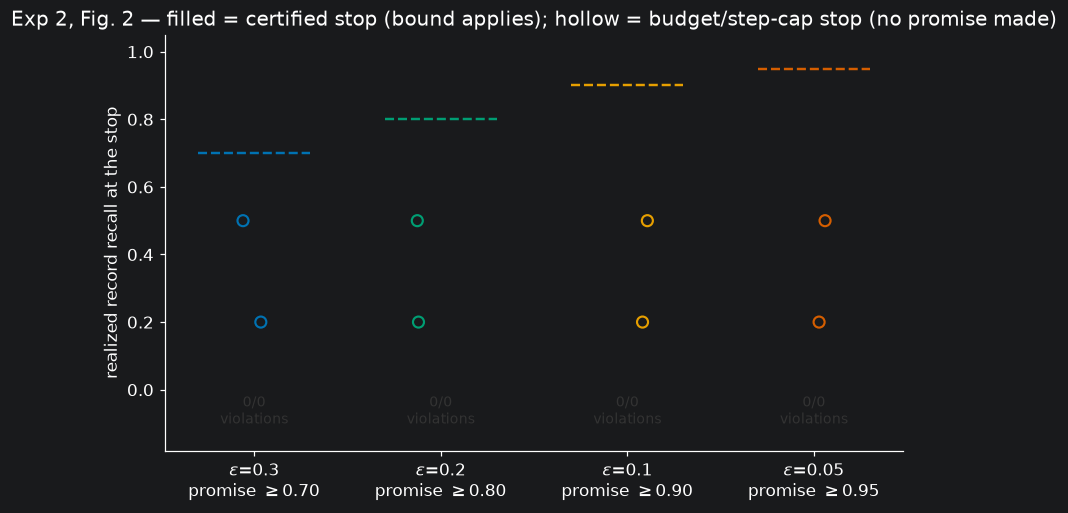

In [9]:
# --- Figure 2: realized recall at the stop vs the promised 1 - eps -----------
rng = np.random.default_rng(0)                      # jitter only, cosmetic
fig, ax = plt.subplots(figsize=(7.6, 4.8))
for i, eps in enumerate(EPS_GRID):
    grp = stops[stops["eps"] == eps]
    x = i + rng.uniform(-0.13, 0.13, len(grp))
    certified = grp["reason"] == "certified"
    ax.scatter(x[certified.values], grp[certified]["record_recall"], s=52,
               color=EPS_COLOR[eps], edgecolor="k", lw=0.5, zorder=5,
               label="_")
    ax.scatter(x[~certified.values], grp[~certified]["record_recall"], s=52,
               facecolor="none", edgecolor=EPS_COLOR[eps], lw=1.4, zorder=4)
    ax.hlines(1 - eps, i - 0.3, i + 0.3, color=EPS_COLOR[eps], ls="--", lw=1.6)
    n_cert = int(certified.sum())
    n_viol = int(grp["violation"].sum())
    ax.text(i, -0.10, f"{n_viol}/{n_cert}\nviolations", ha="center",
            fontsize=9, color="#D55E00" if n_viol else "#333333")
ax.set_xticks(range(len(EPS_GRID)))
ax.set_xticklabels([fr"$\varepsilon$={e}" + "\n" + fr"promise $\geq${1-e:.2f}"
                    for e in EPS_GRID])
ax.set_ylabel("realized record recall at the stop")
ax.set_ylim(-0.18, 1.05)
ax.set_title("Exp 2, Fig. 2 — filled = certified stop (bound applies); "
             "hollow = budget/step-cap stop (no promise made)")
fig.tight_layout()
fig.savefig(FIG_DIR / "exp2_coverage.pdf", bbox_inches="tight")

n_cert = int((stops["reason"] == "certified").sum())
n_viol = int(stops["violation"].sum())
rate = n_viol / max(n_cert, 1)
print(f"certified stops: {n_cert}  violations: {n_viol}  "
      f"rate: {rate:.3f}  (theorem allows <= delta = {DELTA})")

## Figure 3 — one entity's journey (how the rule *feels*)

For a single representative entity: the blue curve is the agent's running belief about how much is
still missing ($\hat U + \psi$, at its binding stratum); the grey steps underneath are the *true*
missing fraction, which the agent could not see. Horizontal lines mark the four promises; a colored
marker shows where each $\varepsilon$-agent went home. Reading it: the curve starts high (everything
unseen), falls as searches stop turning up new rounds, and each agent leaves the moment the curve
drops below *its* line — the strict agent simply stays longest. The dotted spend axis shows what the
extra patience costs.

representative entity: cik0001181412 (SPACE EXPLORATION TECHNOLOGIES CORP)


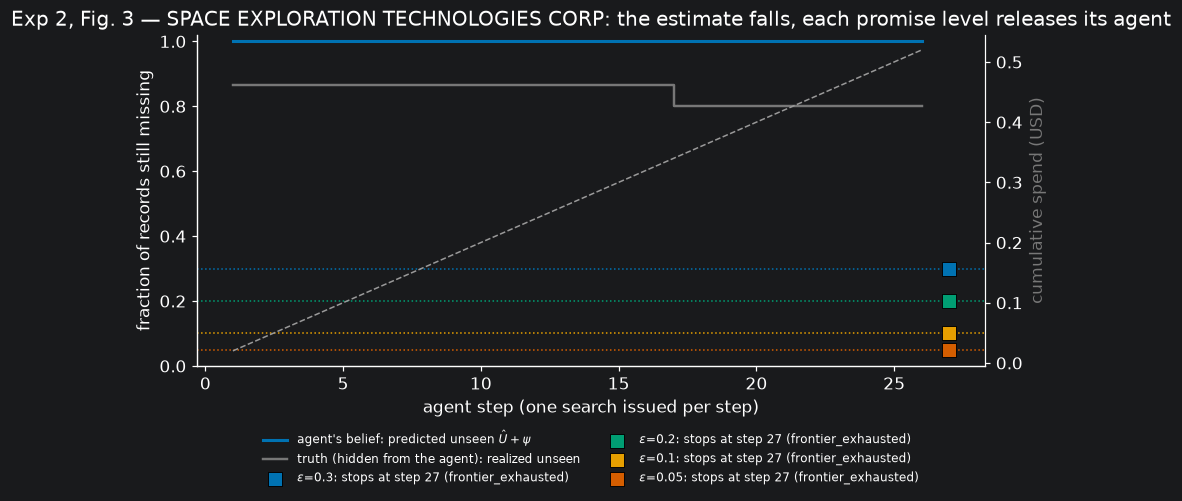

In [10]:
# --- Figure 3: trajectory of the representative entity -----------------------
# representative = the entity with the most certified replay arms, ties by
# most steps (a run where all four stops are visible tells the story best)
cert_counts = (stops[stops["reason"] == "certified"]
               .groupby("entity").size().reindex(done).fillna(0))
rep = cert_counts.sort_values(ascending=False).index[0]
df = step_logs[rep]

per_step = (df[df["certified"].isnull()]
            .groupby("step")
            .apply(lambda g: float((g["U"] + g["psi"]).max()),
                   include_groups=False))
steps_x = per_step.index.to_numpy()
realized = np.array([1 - recall_at(rep, int(t))["record_recall"] for t in steps_x])
spend = df.groupby("step")["spent"].max().reindex(steps_x)

fig, ax = plt.subplots(figsize=(8.6, 4.8))
ax.plot(steps_x, np.minimum(per_step.values, 1.0), color="#0072B2", lw=2,
        label=r"agent's belief: predicted unseen $\hat{U}+\psi$")
ax.plot(steps_x, realized, color="#777777", lw=1.6, drawstyle="steps-post",
        label="truth (hidden from the agent): realized unseen")
for eps in EPS_GRID:
    ax.axhline(eps, color=EPS_COLOR[eps], ls=":", lw=1)
    r = stops[(stops.entity == rep) & (stops.eps == eps)].iloc[0]
    marker = "o" if r.reason == "certified" else "s"
    ax.scatter([r.stop_step], [eps], s=90, marker=marker, zorder=6,
               color=EPS_COLOR[eps], edgecolor="k", lw=0.6,
               label=fr"$\varepsilon$={eps}: stops at step {r.stop_step} ({r.reason})")
ax2 = ax.twinx()
ax2.plot(steps_x, spend, color="#999999", ls="--", lw=1)
ax2.set_ylabel("cumulative spend (USD)", color="#777777")
ax2.spines["right"].set_visible(True)
ax.set_xlabel("agent step (one search issued per step)")
ax.set_ylabel("fraction of records still missing")
ax.set_ylim(0, 1.02)
ax.set_title(f"Exp 2, Fig. 3 — {runs_index[rep]['entity_name']}: "
             "the estimate falls, each promise level releases its agent")
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.16),
          ncol=2, frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / "exp2_trajectory.pdf", bbox_inches="tight")
print(f"representative entity: {rep} ({runs_index[rep]['entity_name']})")

## Figure 4 — what does *knowing when to stop* buy?

A fixed-budget crawler walks the same path but must choose its budget **before seeing any entity** —
one number for everyone. The grey curves show every entity's recall as money is spent; entities differ
wildly, so any single vertical line (one fixed budget) overshoots the easy entities and strands the
hard ones. The adaptive rule instead exits each curve individually (colored dots). The right panel
makes it quantitative for the $\varepsilon = 0.10$ target: for each fixed budget, the fraction of
entities reaching $\ge 0.90$ recall at that spend, versus the stopping rule's certified arms at their
*per-entity* costs — recall at equal cost, or lower cost at equal recall (proposal, Exp 2 setup).

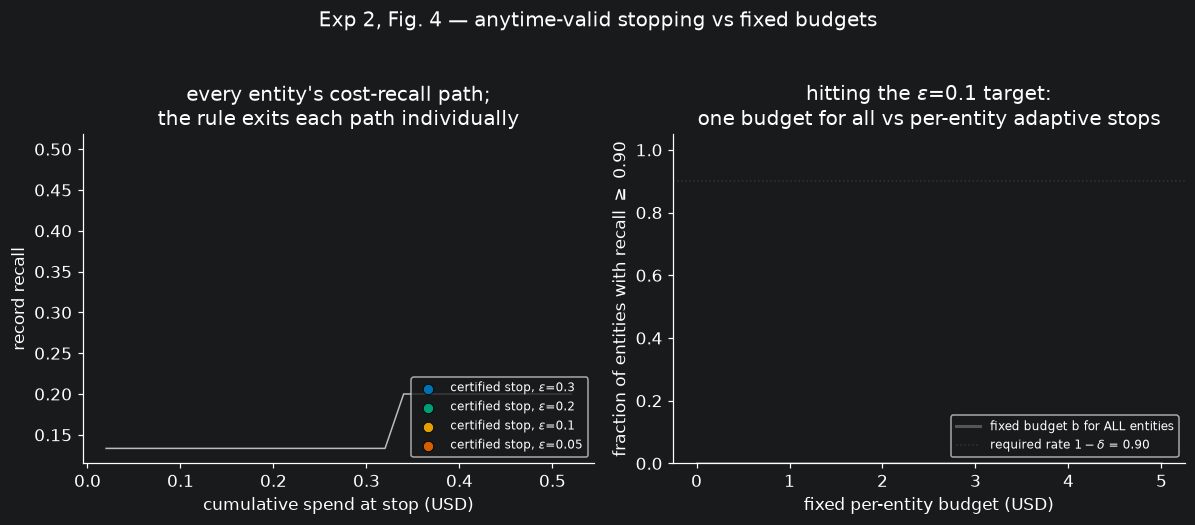

In [11]:
# --- Figure 4: adaptive stopping vs a fixed-budget baseline ------------------
target = 1 - RECALL_TARGET_FOR_FIG4                     # e.g. 0.90 record recall
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.6))

# left: every entity's cost-recall path, with the adaptive exits on top
curves = {}
for eid in done:
    df = step_logs[eid]
    sp = df.groupby("step")["spent"].max()
    rc = np.array([recall_at(eid, int(t))["record_recall"] for t in sp.index])
    curves[eid] = (sp.to_numpy(), rc)
    axL.plot(sp.to_numpy(), rc, color="#BBBBBB", lw=1, zorder=1)
for eps in EPS_GRID:
    sel = stops[(stops["eps"] == eps) & (stops["reason"] == "certified")]
    axL.scatter(sel["spent"], sel["record_recall"], s=46, zorder=5,
                color=EPS_COLOR[eps], edgecolor="k", lw=0.5,
                label=fr"certified stop, $\varepsilon$={eps}")
axL.set_xlabel("cumulative spend at stop (USD)")
axL.set_ylabel("record recall")
axL.set_title("every entity's cost-recall path;\nthe rule exits each path individually")
axL.legend(fontsize=8, loc="lower right")

# right: fixed budget b -> fraction of entities at >= target recall for spend b
budgets = np.linspace(0, BUDGET_USD, 60)
frac = [np.mean([np.interp(b, sp, rc, left=0.0, right=rc[-1]) >= target
                 for sp, rc in curves.values()]) for b in budgets]
axR.plot(budgets, frac, color="#555555", lw=2,
         label="fixed budget b for ALL entities")
sel = stops[(stops["eps"] == RECALL_TARGET_FOR_FIG4)
            & (stops["reason"] == "certified")]
if len(sel):
    axR.scatter([sel["spent"].mean()],
                [np.mean(sel["record_recall"] >= target)], s=120, zorder=6,
                color=EPS_COLOR[RECALL_TARGET_FOR_FIG4], edgecolor="k",
                marker="*",
                label=(f"stopping rule (mean cost "
                       f"${sel['spent'].mean():.2f}/entity)"))
axR.axhline(1 - DELTA, ls=":", color="#333333", lw=1,
            label=fr"required rate $1-\delta$ = {1-DELTA:.2f}")
axR.set_xlabel("fixed per-entity budget (USD)")
axR.set_ylabel(f"fraction of entities with recall $\\geq$ {target:.2f}")
axR.set_ylim(0, 1.05)
axR.set_title(f"hitting the $\\varepsilon$={RECALL_TARGET_FOR_FIG4} target:\n"
              "one budget for all vs per-entity adaptive stops")
axR.legend(fontsize=8, loc="lower right")
fig.suptitle("Exp 2, Fig. 4 — anytime-valid stopping vs fixed budgets", y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / "exp2_cost_recall.pdf", bbox_inches="tight")

## Tables — the paper's numbers

Two CSVs, written next to the figures:

- **`exp2_stop_table.csv`** — one row per (entity, ε): where it stopped, why, what it cost, what it
  achieved, and whether a certified promise was violated. The evaluation section's raw material.
- **`exp2_summary_by_eps.csv`** — the per-ε roll-up the paper quotes directly: certified-stop share,
  violation rate against $\delta$, mean/median cost, mean recall.

In [12]:
# --- summary tables ----------------------------------------------------------
stop_table = stops.copy()
stop_table["entity_name"] = stop_table["entity"].map(
    lambda e: runs_index[e]["entity_name"])
stop_table = stop_table[["entity", "entity_name", "eps", "promised",
                         "stop_step", "reason", "spent",
                         "record_recall", "value_recall", "violation"]]
stop_table.to_csv(EXP_DIR / "exp2_stop_table.csv", index=False)

summary = (stops.groupby("eps")
           .apply(lambda g: pd.Series({
               "n_entities":     len(g),
               "n_certified":    int((g["reason"] == "certified").sum()),
               "n_violations":   int(g["violation"].sum()),
               "violation_rate": g["violation"].sum()
                                 / max((g["reason"] == "certified").sum(), 1),
               "delta_allowed":  DELTA,
               "mean_cost_usd":  g["spent"].mean(),
               "median_cost_usd": g["spent"].median(),
               "mean_stop_step": g["stop_step"].mean(),
               "mean_record_recall": g["record_recall"].mean(),
               "mean_value_recall":  g["value_recall"].mean()}),
                  include_groups=False)
           .reset_index())
summary.to_csv(EXP_DIR / "exp2_summary_by_eps.csv", index=False)
print(f"wrote {EXP_DIR/'exp2_stop_table.csv'}\n"
      f"wrote {EXP_DIR/'exp2_summary_by_eps.csv'}")
summary.round(3)

wrote C:\Users\wangz\PycharmProjects\webagg\data\experiments\exp2\exp2_stop_table.csv
wrote C:\Users\wangz\PycharmProjects\webagg\data\experiments\exp2\exp2_summary_by_eps.csv


,eps,n_entities,n_certified,n_violations,violation_rate,delta_allowed,mean_cost_usd,median_cost_usd,mean_stop_step,mean_record_recall,mean_value_recall
0,0.05,2.0,0.0,0.0,0.0,0.1,NaN,NaN,14.5,0.35,0.303
1,0.10,2.0,0.0,0.0,0.0,0.1,NaN,NaN,14.5,0.35,0.303
2,0.20,2.0,0.0,0.0,0.0,0.1,NaN,NaN,14.5,0.35,0.303
3,0.30,2.0,0.0,0.0,0.0,0.1,NaN,NaN,14.5,0.35,0.303


## Reading the results — the pre-registered verdicts

**C1 (Figure 1).** *Pass:* the point cloud sits on or below the diagonal in the certificate panel;
points may drift above it in the raw-$\hat U$ panel (that is exactly the slack $\psi$ exists to cover).
*Fail:* points above the diagonal in the **certificate** panel falsify Assumption 1(a) — the honest
next step is to report which entities/steps violate and inspect whether Y_CAP under-states the true
per-occasion novelty (the paper's named modeling commitment).

**C2 (Figure 2 + summary table).** *Pass:* `violation_rate ≤ delta_allowed` for every ε among
**certified** stops. Hollow (budget/step-cap) stops are not violations — the system explicitly declined
to promise. *Degenerate pass to watch for:* if almost nothing certifies at strict ε, the guarantee is
real but too conservative to be useful (the proposal's "everything abandoned" bad outcome) — that
belongs in the paper as a finding, with the cost columns quantifying it.

**Value of adaptivity (Figure 4).** The star should sit above the fixed-budget curve at its own mean
cost — same recall for less money, or more recall for the same money. If the curves make any fixed
budget just as good, the stopping machinery is not paying for itself on this cohort (Exp 1's "bad
outcome"), which is honest and reportable.

### Limitations (stated, not hidden)

- **Oracle strictness.** The registry's answer key includes rounds that may exist *nowhere* on the
  open web. Realized recall here is therefore a conservative under-estimate of the agent's recall over
  the *findable* population that Theorem 1 formally speaks about — the honest direction: it can only
  make Figure 1 look worse for us, never better.
- **Per-entity aggregation.** During discovery the rule certifies per stratum; grading is per entity.
  We take the *binding* (worst uncertified) stratum as the entity's prediction — the quantity the stop
  actually waits on.
- **Prefix grading.** Recall at a replayed (earlier) stop uses the final run's entity-resolution
  clusters restricted to mentions available by that step. ER on the exact prefix could differ at the
  margin; at the live stop the grading is exact.
- **Small-$N$ strata.** With a handful of records, $\psi$ dwarfs ε by design (the guide's honesty
  note): such strata are expected to close via checksums or registries (Experiment 5), not statistics —
  their budget/step-cap stops here are the system working as specified, not a failure.